In [2]:
# import
import numpy as np
import seaborn as sns # iris데이터
import pandas as pd   # 원핫인코딩
from sklearn.preprocessing import LabelEncoder # 라벨인코딩(문자->숫자)
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from sklearn.model_selection import train_test_split # 데이터 분할(층화추출로)
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt # 학습과정 시각화

In [3]:
from sklearn import datasets
iris = datasets.load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
# 데이터 생성 및 전처리(라벨인코딩만 하고, 원핫인코딩X)

In [5]:
from sklearn import datasets
iris = datasets.load_iris()
# iris.keys()
iris_X = iris.data
iris_y = iris.target # 라벨인코딩이 되어 있음
iris_X.shape, iris_y.shape
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                   test_size=0.1,
                                                   stratify=iris_y,
                                                   random_state=4)
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((135, 4), (135,), (15, 4), (15,))

# 1. 기본적인 DNN(원핫인코딩X)

In [6]:
# 모델 설정
# model = Sequential()
# model.add(Input(4,))
# model.add(Dense(units=50, activation='relu'))
# model.add(Dense(units=30, activation='relu'))
# model.add(Dense(units=3, activation='softmax'))
model = Sequential([
    Input(4,),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax')
])
model.summary() # 250+1530+93 = 1873개 파라미터

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                250       
                                                                 
 dense_1 (Dense)             (None, 30)                1530      
                                                                 
 dense_2 (Dense)             (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [7]:
# 학습설정
model.compile(loss='sparse_categorical_crossentropy', # 라벨인코딩만 되어 있는 경우
             optimizer='adam',
             metrics=['accuracy'])
# 학습
earlyStropping = EarlyStopping(patience=50) # monitor='val_loss' 기본값
hist = model.fit(train_X, train_y, epochs=1000,
                validation_split=0.2,
                callbacks=[earlyStropping])

Epoch 1/1000
4/4 [==============================] - 1s 123ms/step - loss: 1.0404 - accuracy: 0.3611 - val_loss: 1.0100 - val_accuracy: 0.3704
Epoch 2/1000
4/4 [==============================] - 0s 17ms/step - loss: 0.9570 - accuracy: 0.5648 - val_loss: 0.9428 - val_accuracy: 0.7037
Epoch 3/1000
4/4 [==============================] - 0s 18ms/step - loss: 0.9044 - accuracy: 0.6481 - val_loss: 0.8926 - val_accuracy: 0.7037
Epoch 4/1000
4/4 [==============================] - 0s 15ms/step - loss: 0.8567 - accuracy: 0.6574 - val_loss: 0.8376 - val_accuracy: 0.7037
Epoch 5/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.8129 - accuracy: 0.6574 - val_loss: 0.7870 - val_accuracy: 0.7037
Epoch 6/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.7694 - accuracy: 0.6574 - val_loss: 0.7320 - val_accuracy: 0.7037
Epoch 7/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.7313 - accuracy: 0.6574 - val_loss: 0.6818 - val_accuracy: 0.7037
Epoch 8/1000

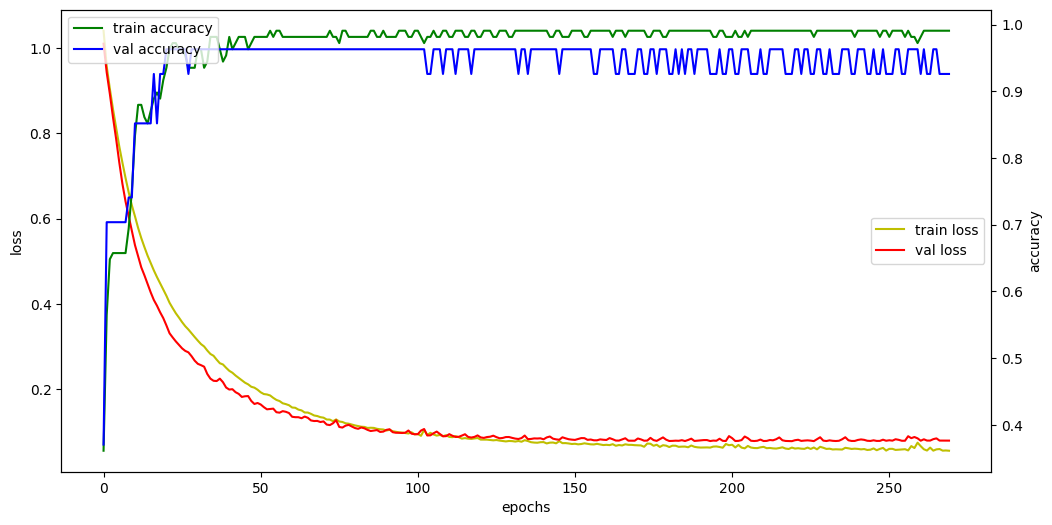

In [8]:
# 5. 모델 학습과정 시각화
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend(loc='upper left')
plt.show()

# 2. sklearn 이용
- 원핫인코딩을 하지 않고 라벨인코딩까지만 해야 작동. numpy배열

In [9]:
from sklearn.neural_network import MLPClassifier

In [10]:
# 머신러닝 3장 교안 43page
mlp_model = MLPClassifier(hidden_layer_sizes=(50,30),
                      activation='relu',
                      solver='adam',
                      alpha=0.0001, # 과적합 방지 강도
                      batch_size=40,
                      max_iter=1000, # epoch
                      early_stopping=True, # 조기 종료 활성화(val_loss)
                      n_iter_no_change=50, # patience
                      warm_start=False, # True일 경우 이전학습에 이어서 학습
                      validation_fraction=0.1, # 검증셋 비율
                      )
mlp_model.fit(train_X, train_y)

MLPClassifier(batch_size=40, early_stopping=True, hidden_layer_sizes=(50, 30),
              max_iter=1000, n_iter_no_change=50)

In [11]:
# # 모델 평가 : accuracy(test_X, test_y), recall, precision(test_y, yhat)
from sklearn.metrics import recall_score, precision_score
accuracy = mlp_model.score(test_X, test_y)
yhat = mlp_model.predict(test_X)
recall = recall_score(test_y, yhat, average='weighted')
precision = precision_score(test_y, yhat, average='weighted')
print('정확도 :', accuracy)
print('재현율 :', recall)
print('정밀도 :', precision)
print('교차표\n :', pd.crosstab(test_y, yhat,
                             rownames=['실제'],
                             colnames=['예측']))

정확도 : 1.0
재현율 : 1.0
정밀도 : 1.0
교차표
 : 예측  0  1  2
실제         
0   5  0  0
1   0  5  0
2   0  0  5


# 3. 클래스 이용

In [12]:
class DNNClassifier:
    @staticmethod
    def build(input_dim=4, activation='relu', optimizer='adam'):
        # model=Sequential()
        # model.add(Input(input_dim,))
        # model.add(Dense(50, activation=activation))
        # model.add(Dense(30, activation=activation))
        # model.add(Dense(3, activation='softmax'))
        model = Sequential([
            Input(input_dim,),
            Dense(50, activation=activation),
            Dense(30, activation=activation),
            Dense(3, activation='softmax'),
        ])
        # 모델 학습 설정
        model.compile(loss='sparse_categorical_crossentropy',
                     optimizer=optimizer,
                     metrics=['accuracy'])
        return model

In [13]:
# 모델
model = DNNClassifier.build(input_dim=4, activation='relu')
model.summary()
# 모델 학습
hist = model.fit(train_X, train_y,
                 epochs=500,
                 validation_split=0.2,
                 verbose=0)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 50)                250       
                                                                 
 dense_4 (Dense)             (None, 30)                1530      
                                                                 
 dense_5 (Dense)             (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [14]:
loss, accuracy = model.evaluate(test_X, test_y)
loss, accuracy

1/1 [==============================] - 0s 27ms/step - loss: 0.0356 - accuracy: 1.0000


(0.03559277206659317, 1.0)

# 4. 함수형 API이용하기
- 병렬처리 : 속도 높이려고
- 레지듀얼블록(Residual block) : 모델의 성능을 높이려고(자연어처리,이미지처리)

In [15]:
# import
import numpy as np
from sklearn.model_selection import train_test_split # 데이터 분할(층화추출로)
from tensorflow.keras import Model # 모델 생성(입력층과 출력층을 이용)
from tensorflow.keras.layers import Dense, Dropout, Input, add
from tensorflow.keras.layers import concatenate
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt # 학습과정 시각화

In [16]:
from sklearn import datasets
iris = datasets.load_iris()
# iris.keys()
iris_X = iris.data
iris_y = iris.target # 라벨인코딩이 되어 있음
iris_X.shape, iris_y.shape
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                   test_size=0.1,
                                                   stratify=iris_y,
                                                   random_state=4)
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((135, 4), (135,), (15, 4), (15,))

In [ ]:
# 기존의 model 스타일 4 -> 50 -> 30 -> 3
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')